In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for local parameters q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for global parameter q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """CAVI update for global parameter q(u)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Runs the inner CAVI loop until convergence for fixed hyperparameters.
        Alternates between updating local (per-point) and global variational parameters.
        """
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # --- 1. Calculate Expectations based on current q distributions ---
            # These expectations are needed for the parameter updates below.
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # --- 2. Update Local Variational Parameters ---
            # Update q(lambda_i) for each data point i.
            self._update_q_lambda(E_q_f, Var_q_f)

            # --- 3. Update Global Variational Parameters ---
            # Update q(r) and q(u), which are shared across all data points.
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            # --- 4. Check for convergence of the variational parameters ---
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = [] # ADDED: To store ELBO values

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            # K matrices are computed once before CAVI, as Z and hypers are fixed during E-step.
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            optimizer = torch.optim.Adam([
                    {'params': [self.log_kernel_lengthscale,
                                self.log_kernel_variance,
                                self.log_likelihood_sigma_sq,
                                self.log_nu_f,
                                self.log_nu_e], 'lr': lr}, # Hyperparameters get the normal learning rate
                    {'params': self.Z, 'lr': lr / 10.0}     # Inducing points get a much smaller learning rate
                ], lr=lr)
            for j in range(max_iter_local):
                # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
                optimizer.zero_grad()
                # ELBO is calculated with current parameters (including Z) to get gradients
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

                # ADDED: Store ELBO for plotting
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # We use .detach() on Z as we don't want prediction to be part of the computation graph.
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()



if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=20, cavi_tol=1e-6)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting optimization with hyperparameter AND inducing point updates...


ELBO: -136.49: 100%|██████████| 1000/1000 [02:20<00:00,  7.12it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.37643254 -5.04157563 -4.13091441 -3.56355513 -2.95223762 -2.39390297
 -1.87418985 -1.33848856 -0.79700203 -0.26766601  0.24438791  0.77882882
  1.29022244  1.82715116  2.42147681  2.930245    3.55729211  4.12805749
  5.02784084  5.69015854]
-------------------


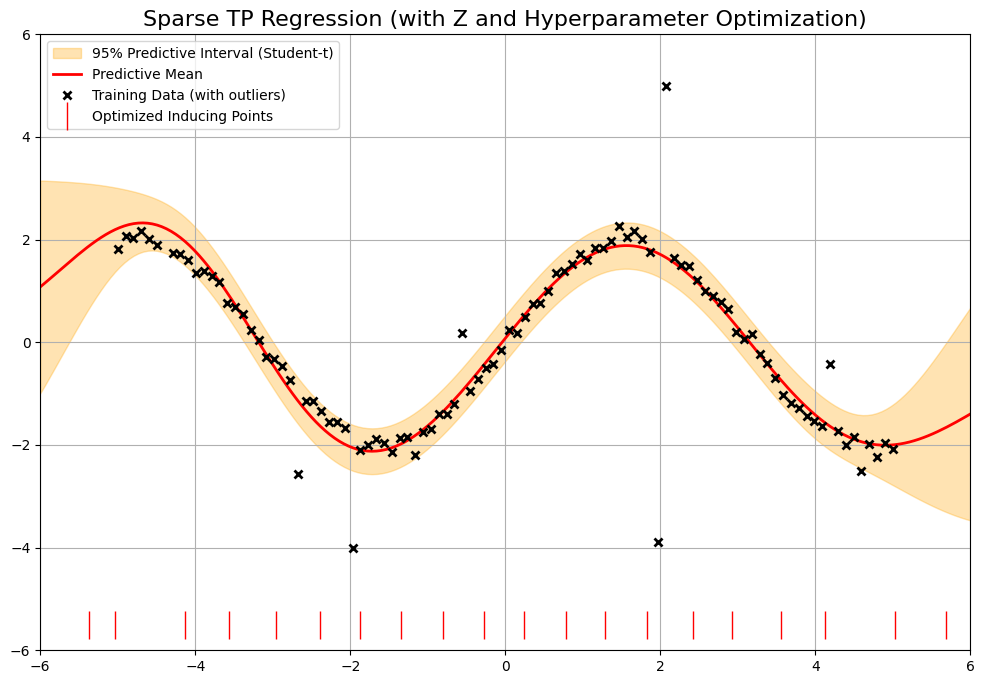

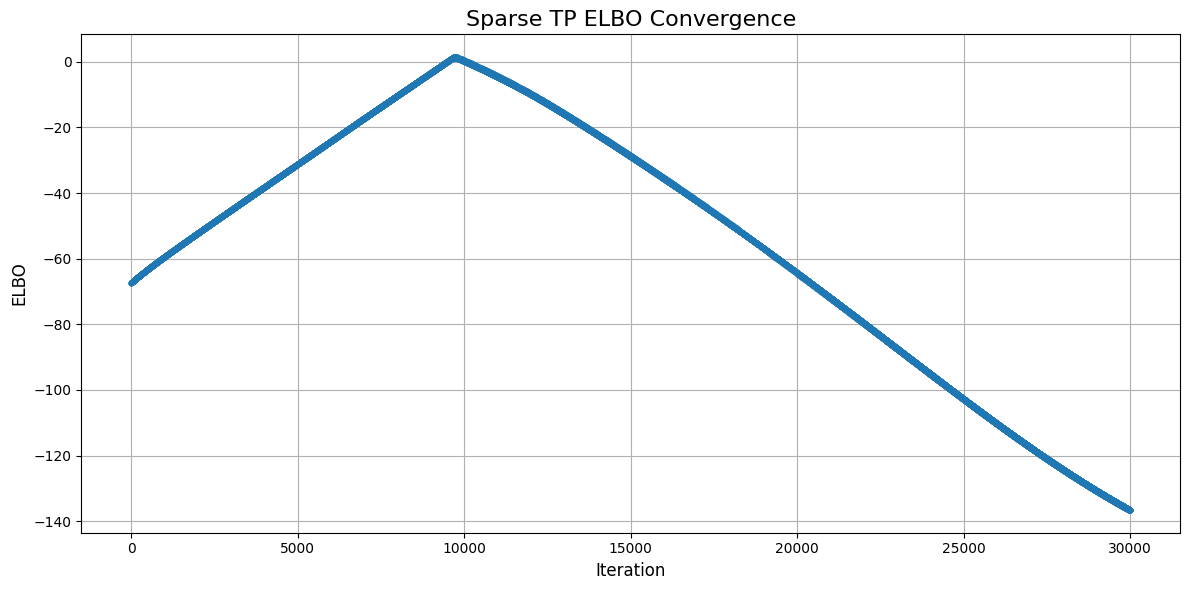

In [16]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=1000, max_iter_local=30, lr=0.0001, cavi_max_iter=20)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so we use register_buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized along with hyperparameters
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are standard tensors.
        self.m_u = torch.zeros(self.M, 1, device=X.device, dtype=X.dtype)
        self.L_u = torch.eye(self.M, device=X.device, dtype=X.dtype) # Cholesky factor of S_u
        self.alpha_r = torch.tensor(1.0, device=X.device, dtype=X.dtype)
        self.beta_r = torch.tensor(1.0, device=X.device, dtype=X.dtype)
        self.alpha_lambda = torch.ones(self.N, 1, device=X.device, dtype=X.dtype)
        self.beta_lambda = torch.ones(self.N, 1, device=X.device, dtype=X.dtype)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for local parameters q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda.fill_(nu_e / 2.0 + 0.5) # Use fill_ for in-place update
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for global parameter q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """
        CORRECTED CAVI update for global parameter q(u).
        This now correctly implements the formulas from the paper.
        """
        _, _, sigma_sq, _, _ = self._get_hyperparams()

        # Get expectations from other q-distributions
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_sigma_sq_lambda = sigma_sq * E_lambda

        # Precompute Kzz inverse
        Kzz_inv = torch.cholesky_solve(torch.eye(self.M, device=self.X.device, dtype=self.X.dtype), Lzz)

        # Calculate the precision matrix (inverse covariance) of q(u)
        precision_from_prior = E_r * Kzz_inv
        
        # This term comes from the likelihood: Kzz_inv @ Kzx @ D_lambda @ Kxz @ Kzz_inv
        # We compute it efficiently
        sum_term = Kxz.T @ (E_sigma_sq_lambda * Kxz)
        precision_from_lik = Kzz_inv @ sum_term @ Kzz_inv

        S_u_inv = precision_from_prior + precision_from_lik
        S_u_inv = 0.5 * (S_u_inv + S_u_inv.T) # Ensure symmetry for numerical stability

        # Compute new covariance S_u and its Cholesky factor L_u
        # Add jitter for stability before Cholesky
        L_S_inv = torch.linalg.cholesky(S_u_inv + torch.eye(self.M, device=self.X.device, dtype=self.X.dtype) * 1e-6)
        S_u = torch.cholesky_solve(torch.eye(self.M, device=self.X.device, dtype=self.X.dtype), L_S_inv)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M, device=self.X.device, dtype=self.X.dtype) * 1e-6)

        # Calculate the `b` term for the mean update: m_u = S_u * b
        b = Kzz_inv @ (Kxz.T @ (E_sigma_sq_lambda * self.y))
        self.m_u = S_u @ b

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Runs the inner CAVI loop until convergence for fixed hyperparameters.
        Alternates between updating local (per-point) and global variational parameters.
        """
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # --- 1. Calculate Expectations needed for the updates ---
            S_u = self.L_u @ self.L_u.T
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            
            E_q_f = Kxz @ Kzz_inv_mu

            # E[r^-1] is needed for Var_q_f
            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            # This calculation of Var_q_f is correct based on the law of total variance
            A = torch.cholesky_solve(Kxz.T, Lzz).T # More stable than solve
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            # E[u^T Kzz^-1 u] is needed for q(r) update
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # --- 2. Update Variational Parameters ---
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            # --- 3. Check for convergence ---
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M, device=self.X.device, dtype=self.X.dtype) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        S_u = self.L_u @ self.L_u.T
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.cholesky_solve(Kxz.T, Lzz).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi, device=self.X.device, dtype=self.X.dtype)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # Entropy of q(u)
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi, device=self.X.device, dtype=self.X.dtype)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        # Entropy of q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # Expected log p(u|r)
        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi, device=self.X.device, dtype=self.X.dtype)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u.squeeze()

        # Expected log p(r)
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = []
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M, device=self.X.device, dtype=self.X.dtype) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo()
            neg_elbo.backward()
            optimizer.step()

            current_elbo = -neg_elbo.item()
            elbo_history.append(current_elbo)
            pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M, device=self.X.device, dtype=self.X.dtype) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.cholesky_solve(K_star_z.T, Lzz).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()



if __name__ == '__main__':
    # --- Use GPU if available ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N, device=device).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1, device=device) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)).to(device) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N, device=device)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M, device=device).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    ).to(device)

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=150, lr=0.01, cavi_max_iter=20)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.cpu().squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.cpu().detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200, device=device).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # Move data to CPU for plotting
    X_train_cpu = X_train.cpu()
    y_train_cpu = y_train.cpu()
    X_test_cpu = X_test.cpu()
    pred_mean_cpu = pred_mean.cpu()
    pred_var_cpu = pred_var.cpu()
    pred_nu_cpu = pred_nu.cpu()
    Z_final_cpu = model.Z.detach().cpu()


    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var_cpu.clamp(min=1e-9))
    df = pred_nu_cpu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean_cpu + lower_quantile * pred_scale
    upper = pred_mean_cpu + upper_quantile * pred_scale

    plt.fill_between(X_test_cpu.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test_cpu, pred_mean_cpu, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train_cpu, y_train_cpu, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(Z_final_cpu, torch.full_like(Z_final_cpu, -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Corrected Sparse TP Regression', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history, marker='.', linestyle='-')
    plt.title('Corrected Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


🚀 Starting training with method: UB


  0%|          | 0/3000 [00:00<?, ?it/s]/tmp/ipykernel_849564/413523767.py:97: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
Epoch 2800 | -ELBO: -683.10 | ν: 2.00 | ν̃: 202.00 | ν_lik: 2.01: 100%|██████████| 3000/3000 [00:13<00:00, 224.67it/s]


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch 2800 | -ELBO: -165.16 | ν: 8.08 | ν̃: 208.08 | ν_lik: 2.03: 100%|██████████| 3000/3000 [00:18<00:00, 165.02it/s]


✓ Training complete for method: MC


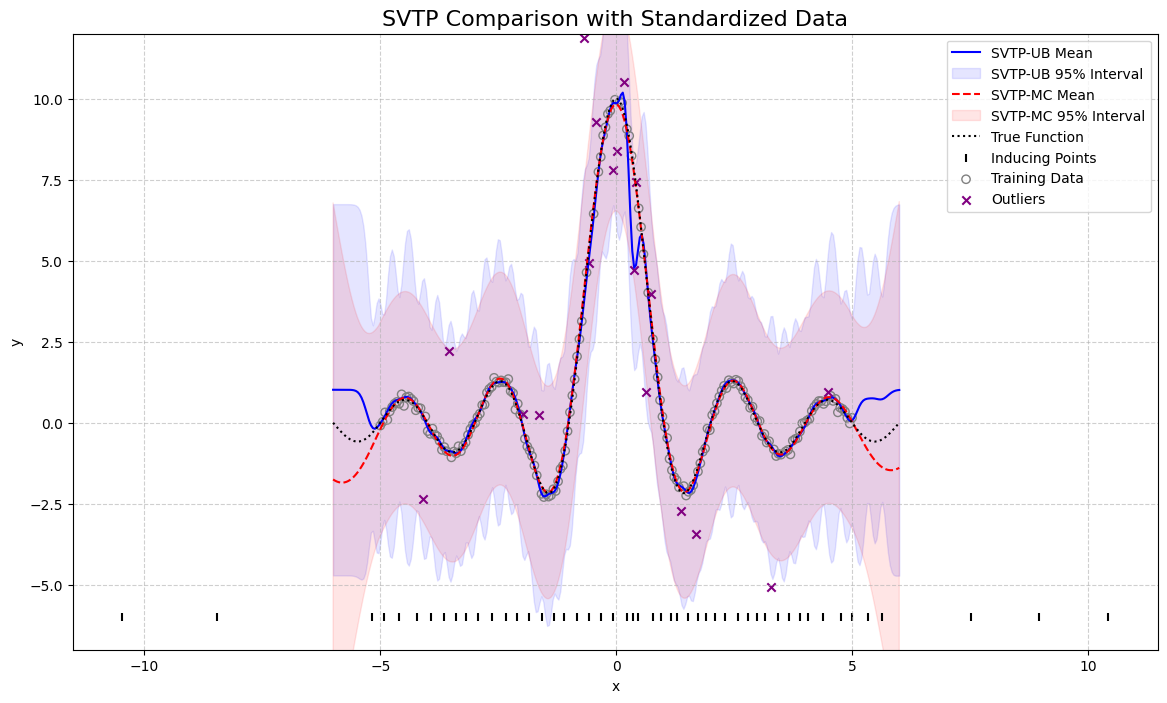

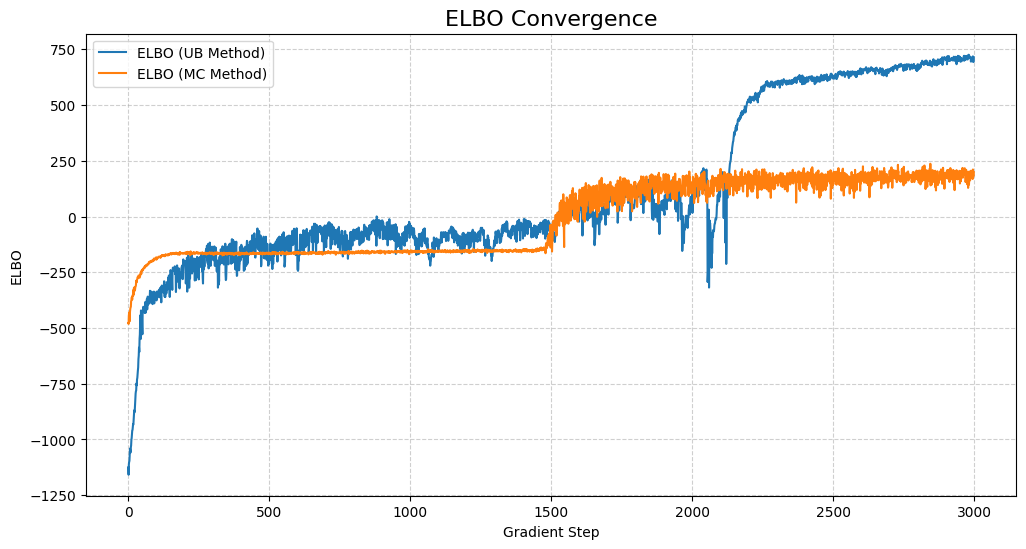

In [6]:
import torch
import torch.nn as nn
from torch.distributions import StudentT, Gamma
import math
import copy
import matplotlib.pyplot as plt
import tqdm

# # For reproducibility
# torch.manual_seed(1234)
torch.set_default_dtype(torch.float64)

# ═══ 1. Helper Function for Student-t Log-PDF ══════════════════════

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    diff = x - mu.unsqueeze(-1)
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2


# ═══ 2. SVTP Model Definition ══════════════════════════════════════

class SVTP(nn.Module):
    def __init__(self, X, y, Z_init):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape[0], X.shape[1] if len(X.shape) > 1 else 1
        self.M = Z_init.shape[0]

        # --- Trainable Parameters ---
        self.Z = nn.Parameter(Z_init)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor(0.1)))
        self.log_nu_lik_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.mu_q = nn.Parameter(torch.zeros(self.M))
        self.S_chol_q = nn.Parameter(torch.eye(self.M))
        
        # REMOVED: self.log_nu_q_minus_2 is no longer a free parameter.

    def _get_params(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        
        # MODIFIED: nu_q is now determined by nu_prior and N, per the paper's finding.
        nu_q = nu_prior + self.N
        
        nu_lik = torch.exp(self.log_nu_lik_minus_2) + 2.0
        sigma_n = torch.exp(self.log_sigma_n)
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        return nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance

    def kernel(self, A, B, variance, lengthscale):
        sq_dist = torch.cdist(A.view(-1, self.D), B.view(-1, self.D), p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
        """Calculates the KL divergence term KL(q(u) || p(u))."""
        if method == 'MC':
            u_samples = self.sample_q_u(nu_q, num_samples=10)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            
            # L1 term
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            
            # L2* term
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            
            # --- CORRECTED LOG-DETERMINANT CALCULATION ---
            # Calculate logdet from the guaranteed positive-definite S_q matrix, not the raw parameter
            sign_S, logdet_S = torch.linalg.slogdet(S_q)
            if sign_S.item() <= 0: return float('inf')

            sign_K, logdet_K = torch.linalg.slogdet(K_mm)
            if sign_K.item() <= 0: return float('inf')
            
            # The term (nu_q - 2) must be handled carefully as nu_q can be large
            log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
            
            C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx

    def expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples=1):
        u_samples = self.sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB', num_samples=1):
        nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_nm = self.kernel(X_batch, self.Z, variance, lengthscale)
        K_mm_inv = torch.inverse(K_mm)

        kl = self.kl_divergence(K_mm, S_q, nu_prior, nu_q, method=kl_method)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def fit(self, epochs, optimizer, kl_method='UB', batch_size=128, num_samples=1):
        """
        Fits the model and returns the history of ELBO values.
        """
        data_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(self.X, self.y), batch_size=batch_size, shuffle=True)
        print(f"🚀 Starting training with method: {kl_method}")
        
        # ADDED: List to store ELBO history
        elbo_history = []
        
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for x_batch, y_batch in data_loader:
                optimizer.zero_grad()
                neg_elbo = -self.elbo(x_batch, y_batch, kl_method=kl_method, num_samples=num_samples)
                
                # ADDED: Store ELBO value at each gradient step
                elbo_history.append(-neg_elbo.item())
                
                if not (torch.isnan(neg_elbo) or torch.isinf(neg_elbo)):
                    neg_elbo.backward()
                    optimizer.step()
            
            if epoch % 200 == 0:
                nu_p, nu_q, nu_l, *_ = self._get_params()
                pbar.set_description(f"Epoch {epoch:4d} | -ELBO: {neg_elbo.item():.2f} | ν: {nu_p.item():.2f} | ν̃: {nu_q.item():.2f} | ν_lik: {nu_l.item():.2f}")
        print(f"✓ Training complete for method: {kl_method}")
        
        # ADDED: Return the history
        return elbo_history

    def predict(self, X_star, num_samples=500):
        with torch.no_grad():
            nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
            K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
            K_star_m = self.kernel(X_star, self.Z, variance, lengthscale)
            K_star_star_diag = torch.diag(self.kernel(X_star, X_star, variance, lengthscale))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self.sample_q_u(nu_q, num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            var_pred = var_f_total + var_likelihood
            return mu_pred, var_pred

# ═══ 3. Example Usage with Standardization ══════════════════════════

if __name__ == '__main__':
    # --- Generate Original Data ---
    N = 200; M = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train) + torch.randn(N, 1) * 0.1
    
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices), 1) * 5
    y_train_orig = y_train_orig.squeeze()

    # --- Standardize Data ---
    x_mean, x_std = X_train.mean(), X_train.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()

    X_train_std = (X_train - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std
    
    # Initialize inducing points from the standardized data
    Z_init_std = X_train_std[torch.randperm(N)[:M]].clone()

    # --- Create Initial Model using Standardized Data ---
    initial_model = SVTP(X_train_std, y_train_std, Z_init_std)

    # --- Train Models ---
    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.01)
    # MODIFIED: Capture the returned history
    elbo_history_ub = model_ub.fit(3000, optimizer_ub, kl_method='UB', batch_size=1024)

    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    # MODIFIED: Capture the returned history
    elbo_history_mc = model_mc.fit(3000, optimizer_mc, kl_method='MC', batch_size=1024)

    # --- Generate and Standardize Test Data ---
    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test - x_mean) / x_std
    
    # --- Get Predictions in Standardized Space ---
    mu_ub_std, var_ub_std = model_ub.predict(X_test_std)
    mu_mc_std, var_mc_std = model_mc.predict(X_test_std)

    # --- Un-standardize Predictions for Plotting ---
    mu_ub = mu_ub_std * y_std + y_mean
    std_ub = torch.sqrt(var_ub_std) * y_std
    
    mu_mc = mu_mc_std * y_std + y_mean
    std_mc = torch.sqrt(var_mc_std) * y_std

    # --- Un-standardize Inducing Points for Plotting ---
    Z_ub_unstd = model_ub.Z.detach() * x_std + x_mean

    # --- Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP Comparison with Standardized Data", fontsize=16)
    
    plt.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test.squeeze(), mu_ub - 2*std_ub, mu_ub + 2*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    
    plt.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test.squeeze(), mu_mc - 2*std_mc, mu_mc + 2*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    plt.plot(X_test, f_true(X_test), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_ub_unstd, torch.full_like(Z_ub_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    
    plt.scatter(X_train[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # ADDED: Plotting ELBO History
    plt.figure(figsize=(12, 6))
    plt.title("ELBO Convergence", fontsize=16)
    plt.plot(elbo_history_ub, label="ELBO (UB Method)")
    plt.plot(elbo_history_mc, label="ELBO (MC Method)")
    plt.xlabel("Gradient Step")
    plt.ylabel("ELBO")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
